In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
class State(TypedDict):
    weather: str
    
graph_builder = StateGraph(State)

In [3]:
def weather_node(state:State)->State:
    print("Checking weather...")
    return state

def rainy_state(state:State)->State:
    print("It;s rainy, take umbrella!")
    return state

def sunny_node(state: State)->State:
    print("It's sunny, wear sunglasses!")
    return state

def weather_routing(state: State) -> str:
    if state["weather"] == "rainy":
        return "rainy"
    elif state["weather"] == "sunny":
        return "sunny"
    else:
        raise ValueError("Invalid weather condition!")
    
graph_builder.add_node("weather_node", weather_node)
graph_builder.add_edge(START, "weather_node")
graph_builder.add_node("rainy", rainy_state)
graph_builder.add_node("sunny", sunny_node)

graph_builder.add_conditional_edges("weather_node",
                                    weather_routing,
                                    ["rainy", "sunny"]
                                    )
graph_builder.add_edge("rainy", END)
graph_builder.add_edge("sunny", END)

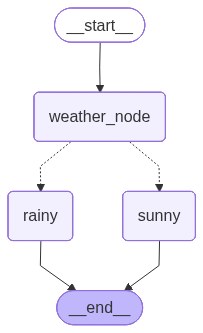

In [4]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))